# Gomoku 9×9 — ANN Heuristic: Training Analysis
Train ANN, plot loss curve, predicted vs actual, error distribution.
Export ONNX model + scaler + report.md (with embedded charts).

**Usage:** Upload `X_data.npy` and `y_data.npy` when prompted.
**Output:** Download 3 PNG charts + `report.md` + `heuristic_predictor.onnx` + `scaler.pkl`.

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
!pip install -q torch onnx onnxruntime scikit-learn joblib numpy matplotlib onnxscript

In [20]:
from google.colab import files
print('Upload X_data.npy and y_data.npy...')
uploaded = files.upload()

Upload X_data.npy and y_data.npy...


Saving X_data.npy to X_data (1).npy
Saving y_data.npy to y_data (1).npy


In [21]:
import torch
import torch.nn as nn

INPUT_SIZE = 81
HIDDEN1 = 256
HIDDEN2 = 128
HIDDEN3 = 64


class HeuristicPredictor(nn.Module):
    def __init__(self, input_size=INPUT_SIZE, hidden1=HIDDEN1, hidden2=HIDDEN2, hidden3=HIDDEN3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden1),
            nn.ReLU(),
            nn.BatchNorm1d(hidden1),
            nn.Dropout(0.3),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.BatchNorm1d(hidden2),
            nn.Dropout(0.3),
            nn.Linear(hidden2, hidden3),
            nn.ReLU(),
            nn.BatchNorm1d(hidden3),
            nn.Linear(hidden3, 1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

In [22]:
import numpy as np
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print('[Train] Loading data...')
X = np.load('/content/X_data.npy')
y = np.load('/content/y_data.npy')
print(f'  X: {X.shape}, y: {y.shape}')

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=42
)
print(f'  Train: {len(X_train)}, Val: {len(X_val)}')

X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).view(-1, 1)
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.FloatTensor(y_val).view(-1, 1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'[Train] Using device: {device}')

[Train] Loading data...
  X: (5832, 81), y: (5832,)
  Train: 4957, Val: 875
[Train] Using device: cpu


In [23]:
model = HeuristicPredictor().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

X_train_t = X_train_t.to(device)
y_train_t = y_train_t.to(device)
X_val_t = X_val_t.to(device)
y_val_t = y_val_t.to(device)

EPOCHS = 200
BATCH_SIZE = 128
best_val_loss = float('inf')
train_losses = []
val_losses = []

print('[Train] Starting training...')
for epoch in range(EPOCHS):
    model.train()
    perm = torch.randperm(len(X_train_t))
    epoch_loss = 0.0
    num_batches = 0

    for i in range(0, len(X_train_t), BATCH_SIZE):
        idx = perm[i:i + BATCH_SIZE]
        X_batch = X_train_t[idx]
        y_batch = y_train_t[idx]

        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t)
        val_loss = criterion(val_pred, y_val_t).item()

    train_loss = epoch_loss / num_batches
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_path = '/content/best_model.pth'
        torch.save(model.state_dict(), best_model_path)

    if epoch % 20 == 0 or epoch == EPOCHS - 1:
        print(f'  Epoch {epoch:3d}: train_loss={train_loss:.6f}, val_loss={val_loss:.6f}')

print(f'[Train] Best val_loss: {best_val_loss:.6f}')

# Load best model
model.load_state_dict(torch.load(best_model_path))
model.eval()

[Train] Starting training...
  Epoch   0: train_loss=0.298668, val_loss=0.218140
  Epoch  20: train_loss=0.152446, val_loss=0.190033
  Epoch  40: train_loss=0.145678, val_loss=0.208549
  Epoch  60: train_loss=0.137675, val_loss=0.236905
  Epoch  80: train_loss=0.131166, val_loss=0.253595
  Epoch 100: train_loss=0.131077, val_loss=0.259010
  Epoch 120: train_loss=0.130438, val_loss=0.262483
  Epoch 140: train_loss=0.131903, val_loss=0.265125
  Epoch 160: train_loss=0.131672, val_loss=0.264336
  Epoch 180: train_loss=0.129169, val_loss=0.275209
  Epoch 199: train_loss=0.126679, val_loss=0.281572
[Train] Best val_loss: 0.170575


HeuristicPredictor(
  (net): Sequential(
    (0): Linear(in_features=81, out_features=256, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Linear(in_features=64, out_features=1, bias=True)
    (12): Tanh()
  )
)

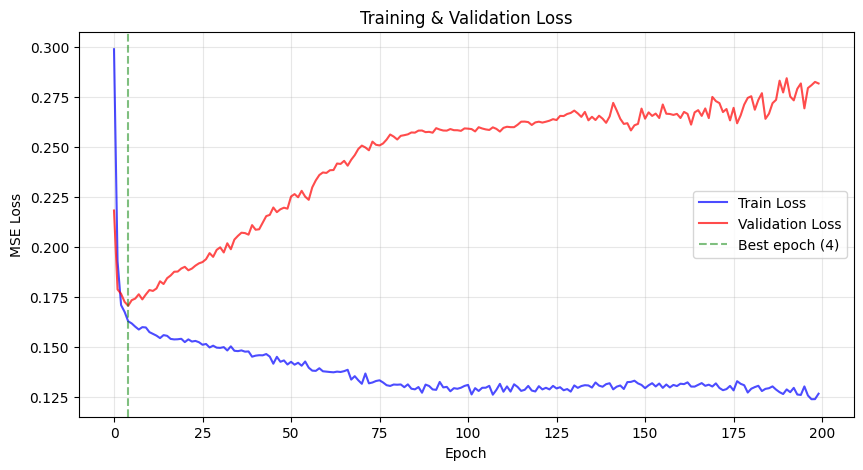

Saved loss_curve.png


In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='blue', alpha=0.7)
plt.plot(val_losses, label='Validation Loss', color='red', alpha=0.7)
best_epoch = int(np.argmin(val_losses))
plt.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.5,
            label=f'Best epoch ({best_epoch})')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved loss_curve.png')

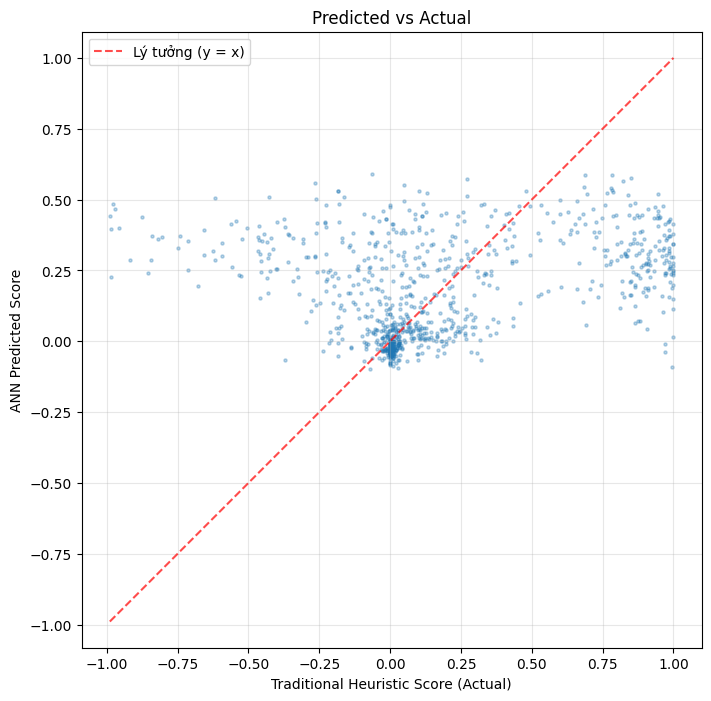

Saved pred_vs_actual.png


In [25]:
with torch.no_grad():
    pred_val = model(X_val_t).cpu().numpy().flatten()

lim_min = min(y_val.min(), pred_val.min())
lim_max = max(y_val.max(), pred_val.max())

plt.figure(figsize=(8, 8))
plt.scatter(y_val, pred_val, alpha=0.3, s=5)
plt.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', alpha=0.7,
         label='Lý tưởng (y = x)')
plt.xlabel('Traditional Heuristic Score (Actual)')
plt.ylabel('ANN Predicted Score')
plt.title('Predicted vs Actual')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.savefig('pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved pred_vs_actual.png')

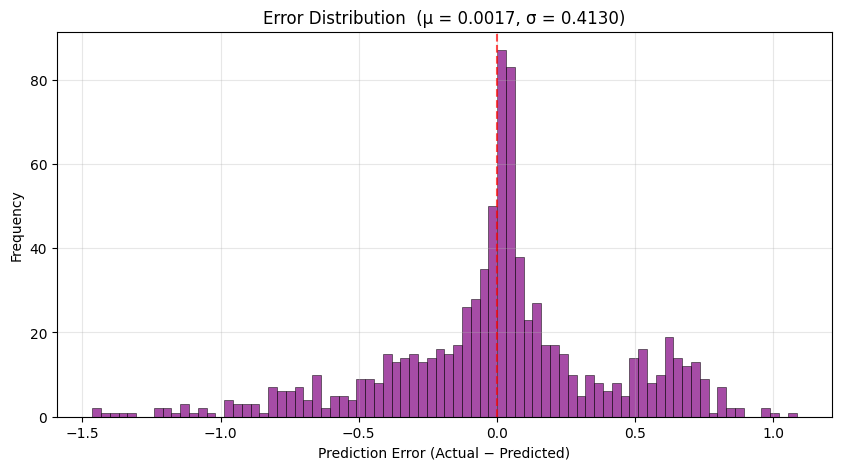

Saved error_distribution.png


In [26]:
errors = y_val - pred_val

plt.figure(figsize=(10, 5))
plt.hist(errors, bins=80, color='purple', alpha=0.7,
         edgecolor='black', linewidth=0.5)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7)
plt.xlabel('Prediction Error (Actual − Predicted)')
plt.ylabel('Frequency')
plt.title(f'Error Distribution  (μ = {errors.mean():.4f}, σ = {errors.std():.4f})')
plt.grid(True, alpha=0.3)
plt.savefig('error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved error_distribution.png')

In [27]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr

r2 = r2_score(y_val, pred_val)
mse = mean_squared_error(y_val, pred_val)
mae = mean_absolute_error(y_val, pred_val)
pearson, p_value = pearsonr(y_val, pred_val)

print('=' * 55)
print('            METRICS REPORT')
print('=' * 55)
print(f'  Samples (train / val):  {len(X_train):>6d} / {len(X_val):<6d}')
print(f'  Epochs:                 {EPOCHS:>12d}')
print(f'  Best val_loss:          {best_val_loss:>12.6f}')
print(f'  R² Score:               {r2:>12.4f}')
print(f'  Pearson Correlation:    {pearson:>12.4f}')
print(f'  p-value:                {p_value:>12.2e}')
print(f'  MSE:                    {mse:>12.6f}')
print(f'  MAE:                    {mae:>12.6f}')
print(f'  Error Mean (μ):         {errors.mean():>12.4f}')
print(f'  Error Std  (σ):         {errors.std():>12.4f}')
print('=' * 55)

            METRICS REPORT
  Samples (train / val):    4957 / 875   
  Epochs:                          200
  Best val_loss:              0.170575
  R² Score:                     0.0286
  Pearson Correlation:          0.2437
  p-value:                    2.69e-13
  MSE:                        0.170575
  MAE:                        0.292669
  Error Mean (μ):               0.0017
  Error Std  (σ):               0.4130


In [28]:
import onnx

dummy = torch.randn(1, 81).to(device)
onnx_path = '/content/heuristic_predictor.onnx'
torch.onnx.export(
    model, dummy, onnx_path,
    input_names=['board_input'],
    output_names=['heuristic_score'],
    dynamic_axes={'board_input': {0: 'batch_size'}}
)
model_onnx = onnx.load(onnx_path)
onnx.save_model(model_onnx, onnx_path, save_as_external_data=False)
print(f'[Export] ONNX model saved to {onnx_path}')

scaler_path = '/content/scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f'[Export] Scaler saved to {scaler_path}')

# Backup to Drive
DRIVE_DIR = '/content/drive/MyDrive/gomoku_models'
os.makedirs(DRIVE_DIR, exist_ok=True)
import shutil
shutil.copy(onnx_path, os.path.join(DRIVE_DIR, 'heuristic_predictor.onnx'))
shutil.copy(scaler_path, os.path.join(DRIVE_DIR, 'scaler.pkl'))
print(f'[Export] Backup copied to {DRIVE_DIR}')

/tmp/ipykernel_2649/2411941270.py:5: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `HeuristicPredictor([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `HeuristicPredictor([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
[Export] ONNX model saved to /content/heuristic_predictor.onnx
[Export] Scaler saved to /content/scaler.pkl
[Export] Backup copied to /content/drive/MyDrive/gomoku_models


In [29]:
corr_str = 'Rất mạnh' if abs(pearson) > 0.9 else 'Mạnh' if abs(pearson) > 0.7 else 'Trung bình'
bias_str = 'tập trung gần 0' if abs(errors.mean()) < 0.1 else 'có độ lệch nhẹ'

report = f"""# ANN Heuristic Predictor — Training Report

## Summary

| Metric | Value |
|--------|-------|
| Samples (train / val) | {len(X_train)} / {len(X_val)} |
| Epochs | {EPOCHS} |
| Best val_loss | {best_val_loss:.6f} |
| R² Score | {r2:.4f} |
| Pearson Correlation | {pearson:.4f} |
| p-value | {p_value:.2e} |
| MSE | {mse:.6f} |
| MAE | {mae:.6f} |
| Error Mean (μ) | {errors.mean():.4f} |
| Error Std (σ) | {errors.std():.4f} |

## Charts

### 1. Loss Curve
![Loss Curve](loss_curve.png)

Training and validation MSE loss over {EPOCHS} epochs. Green dashed line marks the epoch with lowest validation loss (epoch {best_epoch}).

### 2. Predicted vs Actual
![Pred vs Actual](pred_vs_actual.png)

Scatter plot of ANN predictions vs traditional heuristic values on the validation set. The red dashed line indicates ideal perfect prediction (y = x).

### 3. Error Distribution
![Error Distribution](error_distribution.png)

Histogram of prediction errors (actual − predicted). A distribution centered near zero indicates unbiased predictions.

## Interpretation

- **R² = {r2:.4f}**: The ANN explains {r2*100:.1f}% of the variance in the traditional heuristic scores. This is a {'strong' if r2 > 0.8 else 'moderate' if r2 > 0.5 else 'weak'} correlation.
- **Pearson r = {pearson:.4f}**: {corr_str} linear relationship between ANN and traditional heuristic.
- **Error distribution**: The prediction error {bias_str} (μ = {errors.mean():.4f}), suggesting the ANN '{'does not exhibit significant systematic bias' if abs(errors.mean()) < 0.1 else 'may have slight systematic bias'}'.
"""

with open('/content/report.md', 'w', encoding='utf-8') as f:
    f.write(report)
print('report.md created.')

report.md created.


In [30]:
from google.colab import files
files.download('loss_curve.png')
files.download('pred_vs_actual.png')
files.download('error_distribution.png')
files.download('/content/report.md')
files.download(onnx_path)
files.download(scaler_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>